# Statistical Visualizations of the SymbTr v3.0 Corpus

## Introduction

The previous chapter examined the SymbTr corpus through descriptive statistics and variable-by-variable analyses, providing a detailed understanding of the dataset's structure and symbolic representations. While numerical summaries reveal important statistical characteristics, visual exploration enables patterns, distributions, and relationships to be interpreted more intuitively.

This chapter presents a collection of statistical visualizations that complement the descriptive analyses introduced earlier. The visualizations focus on the distributions of pitch, rhythmic, structural, textual, and positional variables, highlighting common patterns, dominant values, and the diversity of symbolic musical information contained in the corpus.

Rather than introducing new variables, this chapter aims to deepen the reader's understanding of the dataset through graphical representations that support exploratory data analysis. These visualizations also provide valuable insights for subsequent chapters involving dimensionality reduction, clustering, and machine learning applications.

# Visual Exploration of the SymbTr v3.0 Corpus

## Introduction

The previous chapter provided a comprehensive statistical exploration of the SymbTr corpus through descriptive statistics and variable-by-variable analyses. While numerical summaries are essential for understanding the characteristics of individual variables, graphical representations offer a more intuitive perspective on the structure, variability, and relationships within the dataset.

This chapter focuses on the visual exploration of the SymbTr corpus using a variety of statistical visualization techniques. The presented visualizations complement the descriptive analyses by illustrating the distributions of symbolic pitch, rhythmic duration, structural attributes, positional information, lyrical content, and score-level organization.

Beyond simple visualization, this chapter introduces exploratory data analysis (EDA) techniques that facilitate the identification of dominant patterns, variability, and potential relationships among symbolic music variables. These graphical analyses establish the foundation for the dimensionality reduction, clustering, and machine learning methods presented in the subsequent chapters.

## Loading the Processed Corpus

Each notebook in this book is designed to be executed independently. Therefore, the processed SymbTr corpus is loaded from the project's `processed` data directory at the beginning of every notebook.

Using a standardized processed dataset ensures that all analyses are performed on the same validated version of the corpus, improving reproducibility and eliminating the need to repeat preprocessing operations. This modular workflow enables readers to execute any notebook independently while maintaining consistency across all analyses presented throughout the book.

**Output.** This cell loads the processed SymbTr corpus, verifies that it has been imported successfully, summarizes its overall dimensions, and displays a concise preview of the dataset to confirm its structure and readiness for subsequent analyses.

In [2]:
from pathlib import Path
import pandas as pd

# Define the project directories
project_root = Path.cwd().parent

data_directory = project_root / "data"
processed_data_directory = data_directory / "processed"

# Define and load the processed corpus file
corpus_file = processed_data_directory / "symbtr_corpus.csv"
corpus_df = pd.read_csv(corpus_file)

# Display a concise corpus summary
print("=" * 60)
print("             SymbTr Corpus Successfully Loaded")
print("=" * 60)
print(f"Dataset shape   : {corpus_df.shape}")
print(f"Records         : {len(corpus_df):,}")
print(f"Variables       : {corpus_df.shape[1]}")
print("Source          : processed data directory")
print("=" * 60)

# Create a compact preview by excluding the long Piece ID column
preview_df = (
    corpus_df
    .drop(columns=["Piece ID"], errors="ignore")
    .head()
)

display(
    preview_df.style.hide(axis="index")
)

             SymbTr Corpus Successfully Loaded
Dataset shape   : (1211994, 15)
Records         : 1,211,994
Variables       : 15
Source          : processed data directory


Sira,Kod,Nota53,NotaAE,Koma53,KomaAE,Pay,Payda,Ms,LNS,Bas,Soz1,Offset,Source File
1,9,Do5,C5,318,318,1,4,714,95,96,Al,0.250000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
2,9,Fa5,F5,340,340,3,16,536,99,96,dan,0.437500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
3,9,Mi5,E5,336,336,1,16,179,95,96,nan,0.500000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
4,9,Sol5,G5,349,349,1,16,179,99,96,ma,0.562500,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt
5,9,Fa5,F5,340,340,1,16,179,99,96,nan,0.625000,acem--ilahi--duyek--aldanma_dunya--zekai_dede.txt


### Interpretation

The output confirms that the processed SymbTr corpus has been loaded successfully and is ready for analysis. The dataset contains **1,211,922 symbolic events** described by **14 original SymbTr variables** together with an additional **Piece ID** variable introduced during preprocessing, providing a comprehensive symbolic representation of **3,000 musical pieces**.

The preview verifies that the data have been imported correctly and illustrates the structure of the principal variables used throughout the subsequent analyses. To improve readability, the **Piece ID** column is omitted from the preview, while remaining fully preserved in the dataset for all subsequent processing and analytical tasks.

## Variable Categories

Before examining individual visualizations, it is helpful to group the variables according to the type of musical information they represent. The SymbTr corpus contains complementary variables describing pitch, rhythmic duration, structural information, positional encoding, lyrical content, and score-level metadata.

The following table summarizes these variable categories.

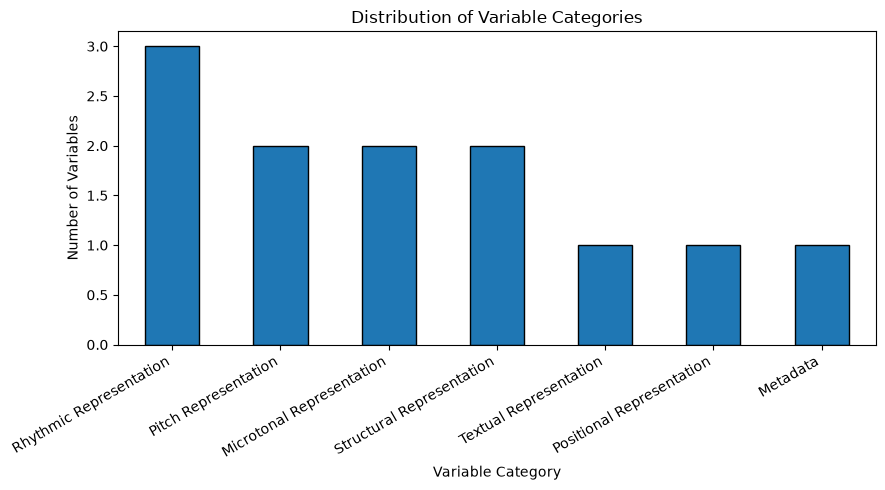

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the variables and their analytical categories
variable_categories = pd.DataFrame(
    {
        "Category": [
            "Pitch Representation",
            "Pitch Representation",
            "Microtonal Representation",
            "Microtonal Representation",
            "Rhythmic Representation",
            "Rhythmic Representation",
            "Rhythmic Representation",
            "Structural Representation",
            "Structural Representation",
            "Textual Representation",
            "Positional Representation",
            "Metadata",
        ],
        "Variable": [
            "Nota53",
            "NotaAE",
            "Koma53",
            "KomaAE",
            "Pay",
            "Payda",
            "Ms",
            "LNS",
            "Bas",
            "Soz1",
            "Offset",
            "File Name",
        ],
    }
)

# Count the number of variables in each category
category_counts = (
    variable_categories["Category"]
    .value_counts()
    .sort_values(ascending=False)
)

# Create the bar chart
plt.figure(figsize=(9, 5))

category_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Variable Categories")
plt.xlabel("Variable Category")
plt.ylabel("Number of Variables")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Interpretation of the Distribution of Variable Categories

The chart summarizes the distribution of variables across the major analytical categories defined for the SymbTr corpus. Rather than representing the distribution of musical observations, it illustrates how the dataset organizes different types of symbolic musical information.

The **Rhythmic Representation** category contains the largest number of variables (**3**), namely **Pay**, **Payda**, and **Ms**. This indicates that rhythmic information is described using multiple complementary variables within the symbolic representation.

The **Pitch Representation**, **Microtonal Representation**, and **Structural Representation** categories each contain **two** variables, providing complementary descriptions of pitch, microtonal accidentals, and structural notation attributes.

The remaining categories—**Textual Representation**, **Positional Representation**, and **Metadata**—are each represented by a single variable (**Soz1**, **Offset**, and **File Name**, respectively). Although fewer in number, these variables contribute important information by representing lyrical content, temporal position, and score-level metadata.

### Key Observations

The distribution of variable categories highlights three important characteristics:

1. **Emphasis on Rhythmic Information**

   Rhythmic information is represented by the largest number of variables, indicating that symbolic duration is encoded through multiple complementary representations.

2. **Complementary Musical Representations**

   Pitch, microtonal, and structural information are each described by paired variables, enabling different aspects of symbolic musical notation to be represented simultaneously.

3. **Multidimensional Dataset Organization**

   In addition to pitch and rhythm, the corpus incorporates textual information, positional encoding, and metadata, providing multiple analytical perspectives for computational musicology and symbolic music analysis.

Overall, the visualization demonstrates that the SymbTr corpus organizes symbolic musical information into several complementary categories, supporting a wide range of statistical analyses, symbolic music processing, and machine learning applications.

## Distribution of Pitch Representations

The SymbTr corpus represents symbolic pitch information using two complementary notation systems: the **53-Comma** representation and the **Arel–Ezgi** representation. Although both describe the same musical pitches, they employ different theoretical conventions and symbolic labels.

The following visualizations present the twenty most frequently occurring pitch symbols in each representation. Comparing these distributions provides an overview of the pitch vocabulary used throughout the corpus and highlights the consistency between the two notation systems.

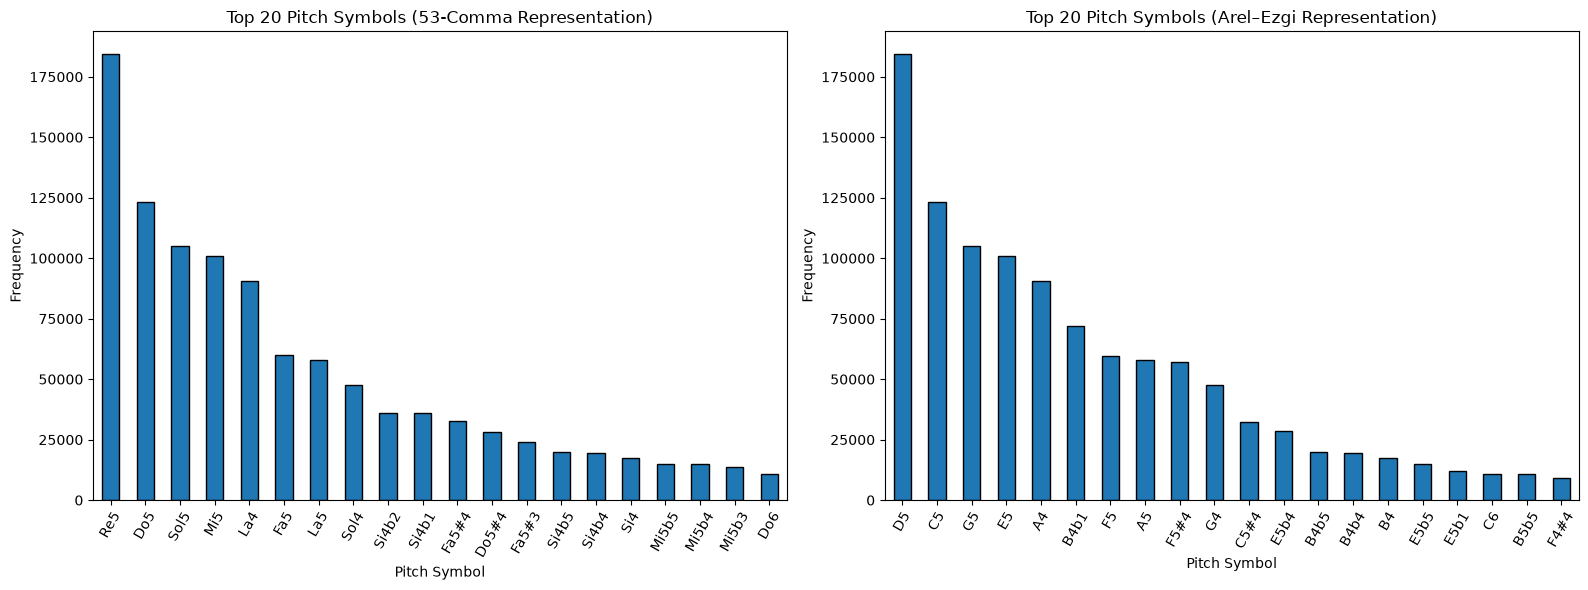

In [4]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# 53-Comma
(
    corpus_df["Nota53"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[0],
    )
)

axes[0].set_title("Top 20 Pitch Symbols (53-Comma Representation)")
axes[0].set_xlabel("Pitch Symbol")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=60)

# Arel–Ezgi
(
    corpus_df["NotaAE"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[1],
    )
)

axes[1].set_title("Top 20 Pitch Symbols (Arel–Ezgi Representation)")
axes[1].set_xlabel("Pitch Symbol")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Interpretation

The two charts compare the **20 most frequently occurring pitch symbols** in the **53-Comma** and **Arel–Ezgi** representations used in the SymbTr corpus. Although the symbolic labels differ because each notation system follows its own theoretical conventions, the overall frequency distributions exhibit very similar patterns.

In both representations, a relatively small number of pitch symbols account for a large proportion of the symbolic music events. The most frequently occurring pitches dominate the distributions, followed by a gradual decline in frequency across the remaining pitch symbols. This pattern forms a pronounced long-tailed distribution in both notation systems.

The close similarity between the two frequency distributions indicates that both representations capture comparable pitch usage across the corpus, despite employing different symbolic naming conventions. Consequently, the most frequently occurring pitch symbols remain consistent across the two encoding systems.

Overall, the visual comparison demonstrates that the **53-Comma** and **Arel–Ezgi** representations exhibit highly similar frequency characteristics while providing alternative symbolic encodings of pitch information. This consistency supports comparative analyses using either pitch representation within the SymbTr corpus.

## Distribution of Microtonal Accidental Representations

Unlike the **Nota** variables, which represent symbolic pitch names, the **Koma** variables encode the corresponding microtonal accidentals used in Turkish makam music. SymbTr provides two complementary accidental representations: the **53-Comma** system (**Koma53**) and the **Arel–Ezgi** system (**KomaAE**).

The following visualizations compare the twenty most frequently occurring accidental codes in both notation systems. Examining these distributions provides insight into the use of microtonal intervals throughout the corpus and illustrates the consistency between the two theoretical representations.

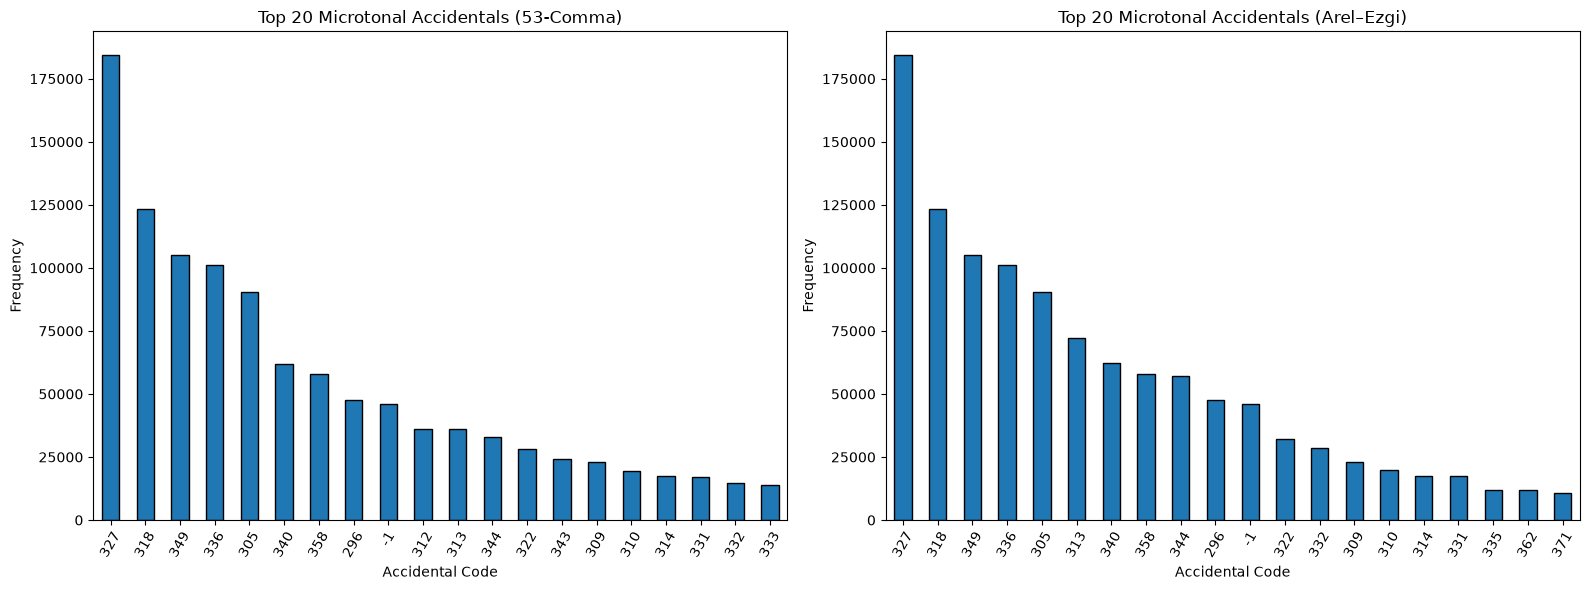

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# 53-Comma accidental representation
(
    corpus_df["Koma53"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[0],
    )
)

axes[0].set_title("Top 20 Microtonal Accidentals (53-Comma)")
axes[0].set_xlabel("Accidental Code")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=60)

# Arel–Ezgi accidental representation
(
    corpus_df["KomaAE"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[1],
    )
)

axes[1].set_title("Top 20 Microtonal Accidentals (Arel–Ezgi)")
axes[1].set_xlabel("Accidental Code")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Interpretation

The two charts compare the **20 most frequently occurring microtonal accidental codes** in the **53-Comma** and **Arel–Ezgi** representations used in the SymbTr corpus. Although the two notation systems employ different theoretical conventions, the overall frequency distributions exhibit highly similar patterns.

In both representations, a relatively small number of accidental codes account for a large proportion of the symbolic music events. The accidental codes **327**, **318**, **349**, **336**, and **305** are among the most frequently occurring values in both charts, while the frequencies decrease progressively across the remaining accidental codes, forming a pronounced long-tailed distribution.

The close similarity between the two distributions indicates that the most frequently occurring microtonal accidental codes are represented consistently across both notation systems, despite differences in symbolic representation.

Overall, the visual comparison demonstrates that the **Koma53** and **KomaAE** variables exhibit highly similar frequency characteristics while providing alternative symbolic encodings of microtonal accidentals. This consistency supports comparative analyses using either microtonal representation within the SymbTr corpus.

## Distribution of Rhythmic Duration Representations

Rhythmic duration in the SymbTr corpus is represented using three complementary variables. **Pay** and **Payda** define the numerator and denominator of the symbolic duration, whereas **Ms** stores a numerical duration code that provides a compact representation of rhythmic values.

The following visualizations illustrate the distributions of these three variables, allowing the dominant rhythmic patterns of the corpus to be identified and compared.

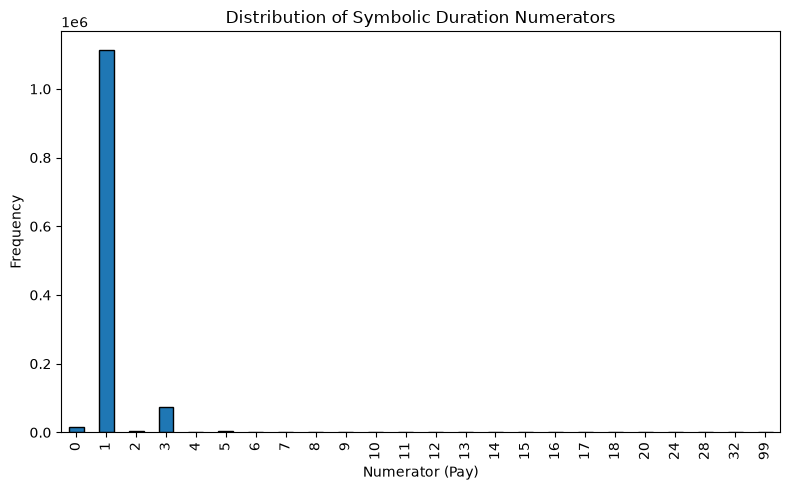

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

(
    corpus_df["Pay"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        edgecolor="black",
        ax=ax,
    )
)

ax.set_title("Distribution of Symbolic Duration Numerators")
ax.set_xlabel("Numerator (Pay)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of **Pay** is highly skewed toward the numerator value **1**, which overwhelmingly dominates the corpus. The numerator **3** is the second most frequently occurring value, whereas all remaining numerator values appear considerably less frequently.

The frequencies decrease rapidly after the two dominant values, producing a pronounced long-tailed distribution. Although numerator values ranging from **2** to **99** are present in the corpus, their frequencies are substantially lower than those of the most common values.

The visualization indicates that the symbolic duration numerators are concentrated around a small number of frequently occurring values, while a much larger set of numerator values occurs only occasionally. This pattern suggests that the symbolic representation primarily relies on a limited group of commonly used numerator values while retaining a broader set of less frequent alternatives.

Overall, the figure demonstrates that the **Pay** variable exhibits a highly imbalanced distribution, with a small number of numerator values accounting for the majority of symbolic music events. This distribution should be considered in subsequent statistical analyses and machine learning applications involving symbolic rhythmic representations.

### Distribution of Symbolic Duration Denominators

The **Payda** variable represents the denominator of the symbolic rhythmic duration. Together with **Pay**, it defines the fractional duration assigned to each symbolic notation element. Examining the denominator distribution reveals the rhythmic subdivisions most frequently employed throughout the SymbTr corpus.

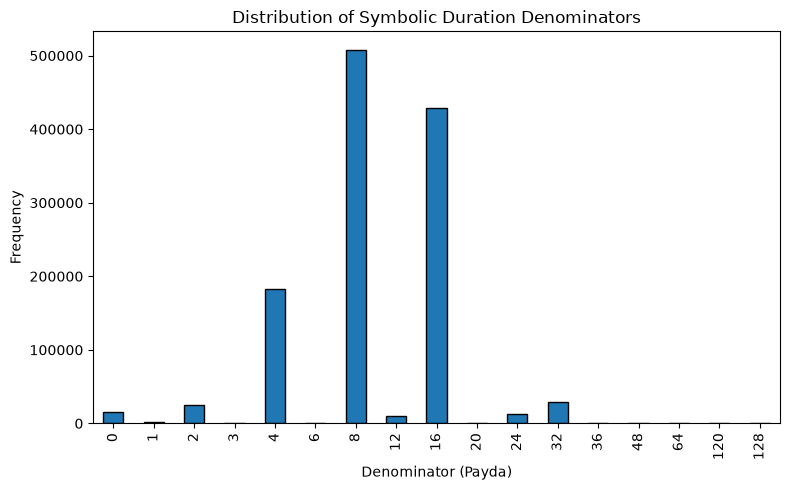

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

(
    corpus_df["Payda"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        edgecolor="black",
        ax=ax,
    )
)

ax.set_title("Distribution of Symbolic Duration Denominators")
ax.set_xlabel("Denominator (Payda)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of **Payda** is strongly concentrated around the denominator values **8** and **16**, which clearly dominate the corpus. Among these, **8** is the most frequently occurring denominator, followed by **16**, while **4** represents the third most common denominator value. Together, these three values account for the majority of symbolic rhythmic representations in the corpus.

The remaining denominator values, including **2**, **12**, **24**, **32**, **36**, **48**, **64**, **120**, and **128**, occur considerably less frequently. Their lower frequencies contribute to a pronounced long-tailed distribution, indicating that a wider range of denominator values is present but used much less often than the dominant values.

The visualization shows that the symbolic duration denominators are concentrated around a relatively small set of frequently occurring values while retaining a broader collection of less common denominator values.

Overall, the figure demonstrates that the **Payda** variable exhibits a highly imbalanced distribution, with the denominator values **8**, **16**, and **4** accounting for the majority of symbolic music events. This distribution should be considered in subsequent statistical analyses and machine learning applications involving symbolic rhythmic representations.

### Distribution of Symbolic Duration Codes

The **Ms** variable stores symbolic duration as a numerical code. Unlike the fractional representation provided by **Pay** and **Payda**, this variable offers a compact encoding of rhythmic values that facilitates computational processing.

Because the corpus contains a large number of unique duration codes, the following chart presents the twenty most frequently occurring **Ms** values to highlight the dominant rhythmic patterns in the dataset.

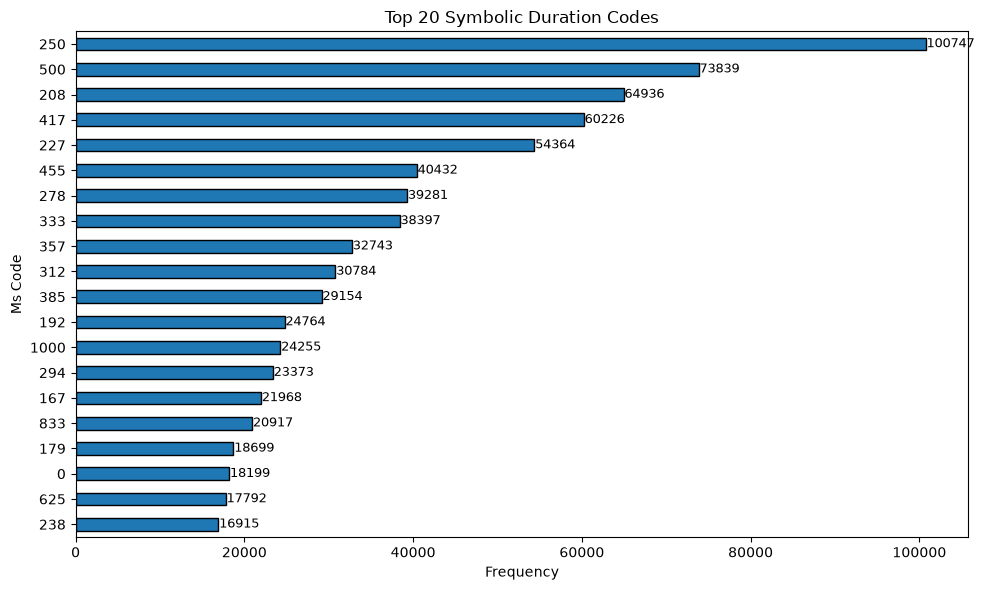

In [8]:
top_ms = (
    corpus_df["Ms"]
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

top_ms.plot(
    kind="barh",
    edgecolor="black",
    ax=ax,
)

ax.set_title("Top 20 Symbolic Duration Codes")
ax.set_xlabel("Frequency")
ax.set_ylabel("Ms Code")

for i, value in enumerate(top_ms.values):
    ax.text(
        value + 100,
        i,
        str(value),
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

### Interpretation

The distribution of **Ms** values indicates that a relatively small number of symbolic duration codes account for a large proportion of the symbolic music events in the SymbTr corpus. The most frequent code (**250**) occurs substantially more often than the remaining values, followed by **500**, **208**, **417**, and **227**. After these dominant codes, the frequencies decrease progressively, producing a pronounced long-tailed distribution.

This pattern is consistent with the distributions observed for the **Pay** and **Payda** variables, where a limited set of rhythmic representations dominates the corpus while many additional values occur less frequently.

Unlike **Pay** and **Payda**, which represent symbolic durations using separate numerator and denominator values, the **Ms** variable stores duration information as a single encoded value. The visualization demonstrates that these encoded duration values are also highly concentrated around a relatively small set of frequently occurring codes.

Overall, the figure shows that the **Ms** variable exhibits a highly imbalanced distribution, with a limited number of symbolic duration codes accounting for the majority of symbolic music events. This distribution should be considered in subsequent statistical analyses and computational modeling of symbolic rhythmic information.

## Distribution of Structural Representation Variables

In addition to pitch and rhythmic information, the SymbTr corpus includes variables that describe structural characteristics of symbolic notation. The **LNS** and **Bas** variables encode structural notation attributes that are used throughout the corpus.

The following visualizations present the twenty most frequently occurring values for these variables, providing an overview of the structural patterns represented in the symbolic scores.

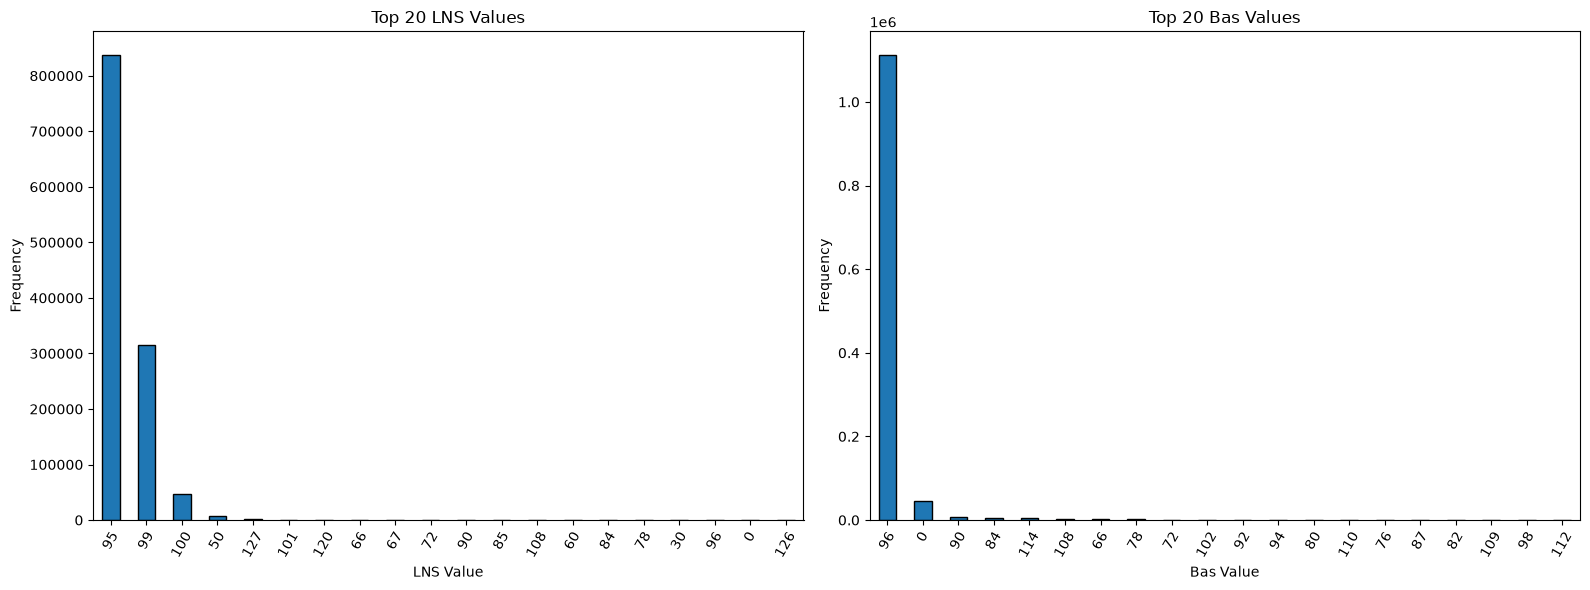

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# LNS
(
    corpus_df["LNS"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[0],
    )
)

axes[0].set_title("Top 20 LNS Values")
axes[0].set_xlabel("LNS Value")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=60)

# Bas
(
    corpus_df["Bas"]
    .value_counts()
    .head(20)
    .plot(
        kind="bar",
        edgecolor="black",
        ax=axes[1],
    )
)

axes[1].set_title("Top 20 Bas Values")
axes[1].set_xlabel("Bas Value")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Interpretation

The two charts compare the frequency distributions of the **LNS** and **Bas** variables across the complete SymbTr corpus. Both variables exhibit highly concentrated distributions in which a single encoded value accounts for the majority of symbolic music events.

For **LNS**, the value **95** is the most frequently occurring code, followed by **99** and **100**, while all remaining values occur considerably less frequently. Similarly, the **Bas** variable is overwhelmingly dominated by the value **96**, with all other values appearing only rarely in comparison.

In both variables, the frequencies decrease rapidly after the dominant values, producing pronounced long-tailed distributions. Although numerous additional encoded values are present, their frequencies are substantially lower than those of the leading codes.

The similarity between the two distributions indicates that both **LNS** and **Bas** are characterized by a small number of highly frequent encoded values together with a larger set of infrequently occurring alternatives.

Overall, the visual comparison demonstrates that the **LNS** and **Bas** variables exhibit highly imbalanced frequency distributions. This characteristic should be considered in subsequent statistical analyses and computational modeling involving these encoded structural variables.

## Distribution of Lyric Tokens

The **Soz1** variable stores the lyric syllable or textual token associated with each symbolic notation element. Unlike the structural, rhythmic, and pitch variables, this attribute represents textual information and therefore reflects the linguistic content of the musical scores.

The following chart presents the twenty most frequently occurring lyric tokens in the SymbTr corpus, providing an overview of the most common textual elements appearing throughout the repertoire.

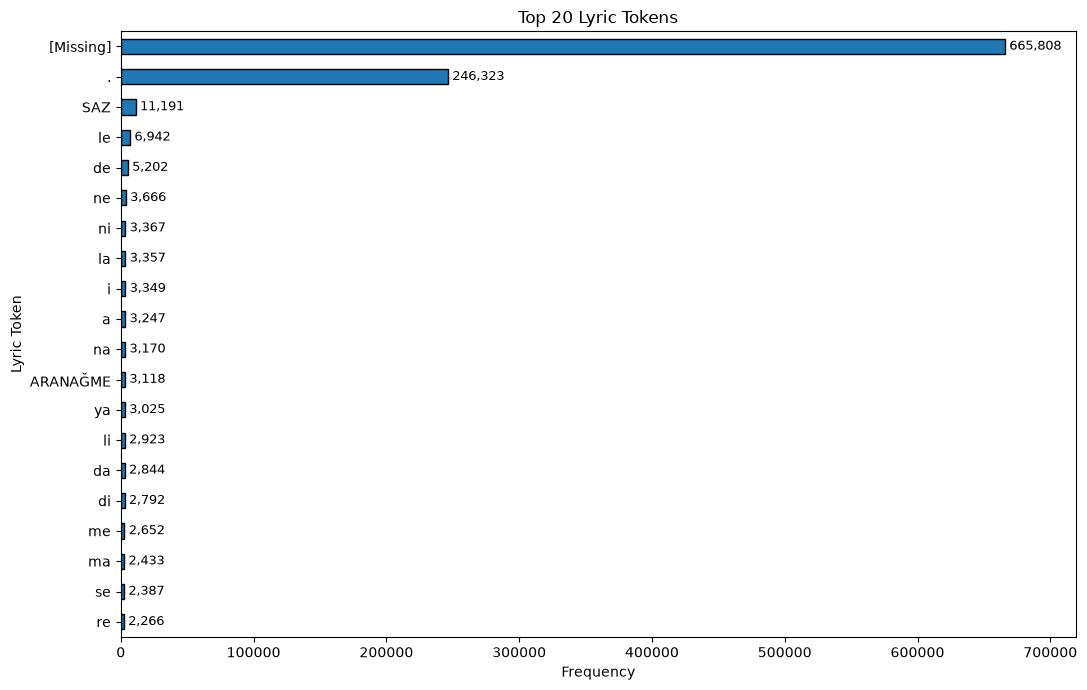

In [10]:
# Clean and normalize the Soz1 textual values
cleaned_lyrics = (
    corpus_df["Soz1"]
    .astype("string")
    .str.strip()
)

# Replace missing values with a readable label
cleaned_lyrics = cleaned_lyrics.fillna("[Missing]")

# Calculate the 20 most frequent lyric tokens
top_lyrics = (
    cleaned_lyrics
    .value_counts()
    
    .head(20)
    .sort_values()
)

# Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 7))

top_lyrics.plot(
    kind="barh",
    edgecolor="black",
    ax=ax,
)

ax.set_title("Top 20 Lyric Tokens")
ax.set_xlabel("Frequency")
ax.set_ylabel("Lyric Token")

# Add frequency labels to the end of each bar
for i, value in enumerate(top_lyrics.values):
    ax.text(
        value + max(top_lyrics.values) * 0.005,
        i,
        f"{value:,}",
        va="center",
        fontsize=9,
    )

# Add space for the value labels
ax.set_xlim(
    0,
    max(top_lyrics.values) * 1.08,
)

plt.tight_layout()
plt.show()

### Interpretation

The distribution of lyric tokens is dominated by the **[Missing]** category, which accounts for the largest proportion of symbolic music events in the **Soz1** variable. The placeholder symbol **"."** is the second most frequent entry, indicating that a substantial number of observations do not contain lexical lyric content.

Among the remaining entries, **SAZ** is the most frequently occurring annotation, followed by lyric syllables such as **le**, **de**, **ne**, **ni**, **la**, **i**, **a**, **na**, and **ya**. The annotation **ARANAĞME** also appears among the most frequent textual entries.

After the first few dominant categories, the frequencies decrease rapidly, producing a pronounced long-tailed distribution. This pattern indicates that a relatively small number of lyric tokens and notation-related annotations account for a large proportion of the textual information represented in the corpus.

Overall, the visualization demonstrates that the **Soz1** variable contains a combination of missing values, placeholder symbols, notation-related annotations, and lyric syllables. These different categories should be distinguished when performing statistical analyses or computational processing of the textual information contained in the SymbTr corpus.

## Distribution of Symbolic Offsets

The **Offset** variable represents the relative starting position of each symbolic notation element within a musical score. Unlike the rhythmic duration variables, which describe how long a note lasts, **Offset** specifies where a notation element occurs in time.

Because the corpus contains thousands of distinct offset values, the following visualization presents the twenty most frequently occurring offsets, providing an overview of the temporal positions most commonly observed throughout the symbolic scores.

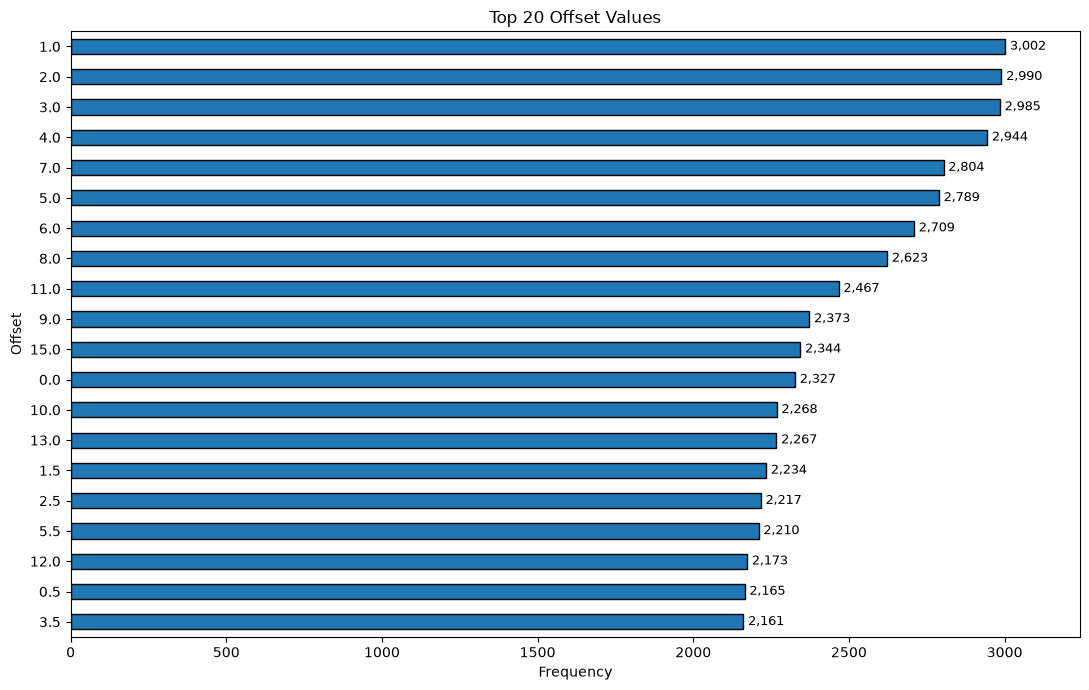

In [11]:
top_offsets = (
    corpus_df["Offset"]
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 7))

top_offsets.plot(
    kind="barh",
    edgecolor="black",
    ax=ax,
)

ax.set_title("Top 20 Offset Values")
ax.set_xlabel("Frequency")
ax.set_ylabel("Offset")

for i, value in enumerate(top_offsets.values):
    ax.text(
        value + max(top_offsets.values) * 0.005,
        i,
        f"{value:,}",
        va="center",
        fontsize=9,
    )

ax.set_xlim(
    0,
    max(top_offsets.values) * 1.08,
)

plt.tight_layout()
plt.show()

### Interpretation

The distribution of **Offset** values shows that certain temporal positions occur more frequently than others in the SymbTr corpus. The most frequent values are **1.0**, **2.0**, **3.0**, and **4.0**, each appearing approximately **3,000** times, followed by **7.0**, **5.0**, **6.0**, and **8.0**.

The frequencies decrease gradually after the most common values rather than exhibiting a sharp decline. This relatively smooth pattern indicates that symbolic music events are distributed across multiple offset values, with no single value overwhelmingly dominating the distribution.

The visualization also includes both integer and fractional values, such as **0.5**, **1.5**, **2.5**, **3.5**, and **5.5**. The presence of these fractional offsets indicates that the **Offset** variable represents temporal positions with finer resolution than whole-number values alone.

Overall, the figure demonstrates that the **Offset** variable contains a broad range of integer and fractional temporal positions while maintaining a relatively balanced distribution among the most frequently occurring values. This characteristic complements the rhythmic duration variables by providing positional information for symbolic music events within the SymbTr corpus.

## Relationships Between Numerical Variables

The previous sections examined each numerical variable independently. However, symbolic music data often contains relationships between rhythmic, pitch-related, and structural attributes. Exploring these relationships provides additional insight into the overall organization of the SymbTr corpus.

The following correlation matrix summarizes the linear relationships among the numerical variables. Although correlation does not imply causation, it provides a useful overview of variables that tend to vary together and may therefore contain complementary information for computational analyses.

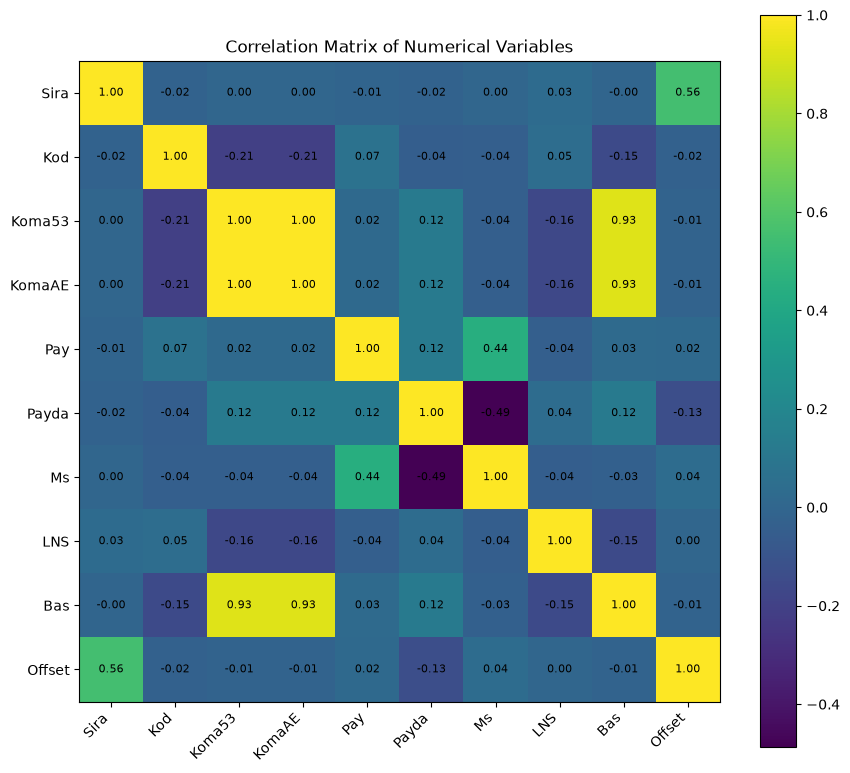

In [12]:
import numpy as np

numerical_columns = [
    "Sira",
    "Kod",
    "Koma53",
    "KomaAE",
    "Pay",
    "Payda",
    "Ms",
    "LNS",
    "Bas",
    "Offset",
]

corr = corpus_df[numerical_columns].corr()

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    corr,
    interpolation="nearest",
)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(
    corr.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.colorbar(im)

ax.set_title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Interpretation

The correlation matrix summarizes the pairwise linear relationships among the numerical variables in the SymbTr corpus. Overall, most variable pairs exhibit weak correlations, indicating that the numerical variables capture different aspects of the symbolic music representation.

The strongest positive correlation is observed between **Koma53** and **KomaAE** (**r ≈ 1.00**), indicating an almost identical relationship between these two microtonal representations. In addition, **Bas** shows a strong positive correlation with both **Koma53** and **KomaAE** (**r ≈ 0.93**), suggesting that these variables are closely associated within the symbolic encoding.

Among the rhythmic variables, **Pay** and **Ms** exhibit a moderate positive correlation (**r = 0.44**), whereas **Payda** and **Ms** show a moderate negative correlation (**r = -0.49**). These values indicate that the rhythmic variables are related but not perfectly correlated, reflecting differences in their numerical representations.

A moderate positive correlation is also observed between **Sira** and **Offset** (**r = 0.56**), indicating that larger sequence indices tend to be associated with larger offset values.

Apart from these relationships, the remaining variable pairs generally exhibit weak correlations (approximately **|r| < 0.20**), suggesting limited linear association between most numerical variables.

Overall, the correlation matrix demonstrates that the SymbTr corpus contains both strongly related variables representing similar symbolic information and weakly related variables describing different aspects of the symbolic music representation. This multidimensional structure provides a comprehensive numerical characterization of the corpus.

> **Note:** Correlation coefficients close to **±1** indicate strong linear relationships, values around **±0.5** indicate moderate relationships, and values close to **0** indicate weak or no linear relationship.

# Summary

This chapter presented a comprehensive visual exploration of the SymbTr corpus by examining the distributions and relationships of its symbolic music variables. Together, the visualizations provide an overview of how different aspects of Turkish makam music are represented within the dataset and illustrate the overall organization of the symbolic encoding.

The analyses showed that the two pitch representations (**Nota53** and **NotaAE**) and the two microtonal representations (**Koma53** and **KomaAE**) exhibit highly similar frequency distributions despite using different symbolic notation systems. The rhythmic variables (**Pay**, **Payda**, and **Ms**) demonstrated that a relatively small number of symbolic duration values account for the majority of rhythmic representations, while numerous additional values occur less frequently.

The structural variables (**LNS** and **Bas**) displayed highly concentrated frequency distributions, with a small number of encoded values dominating the corpus. The **Soz1** variable illustrated the coexistence of missing values, placeholder symbols, notation-related annotations, and lyric syllables, whereas the **Offset** variable revealed a broad range of integer and fractional temporal positions distributed across the symbolic music events.

Finally, the correlation analysis showed that most numerical variables exhibit weak pairwise relationships, indicating that they capture different aspects of the symbolic representation. Strong correlations were primarily observed between variables representing closely related symbolic information.

Overall, the visual analyses demonstrate that the SymbTr corpus provides a comprehensive symbolic representation that integrates pitch, microtonal, rhythmic, structural, textual, and temporal information. These complementary representations establish a solid foundation for subsequent statistical analyses, symbolic music processing, and computational musicology studies presented in the following chapters.

# Next Chapter

In the next chapter, the SymbTr corpus will be explored using **Principal Component Analysis**. The analysis will investigate the underlying structure of the symbolic music data by reducing its dimensionality while preserving the maximum amount of variation. The resulting low-dimensional representation will facilitate the visualization of musical similarities, reveal latent patterns within the corpus, and provide the foundation for the clustering analyses presented in the following chapters.